Fitted parameters: Ie = 24090.35, re = 1.72, n = 0.50


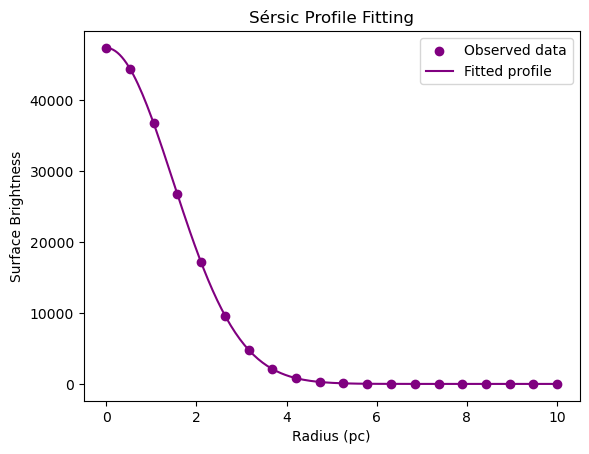

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = [
  0.00,  47373.98,
  0.53,  44447.19,
  1.05,  36728.40,
  1.58,  26730.46,
  2.11,  17122.92,
  2.63,  9643.88,
  3.16,  4806.90,
  3.68,  2109.92,
  4.21,  793.68,
  4.74,  289.23,
  5.26,  93.78,
  5.79,  32.29,
  6.32,  14.18,
  6.84,  3.27,
  7.37,  5.26,
  7.89,  2.89,
  8.42,  1.83,
  8.95,  0.82,
  9.47,  0.61,
  10.00, 0.93
]

radii, brightness = data[0::2], data[1::2] #the slicing was wrong

def sersic_profile(r, Ie, re, n):
    """
    Sérsic profile:
    I(r) = Ie * exp(-bn * ((r/re)^(1/n) - 1))
    bn can be approximated as 2n - 0.324
    """
    bn = 2 * n - 0.324 #was wrong aswell
    return Ie * np.exp(-bn * ((r / re) ** (1/n) - 1)) #the formula was wrong, it is now correct

popt, pcov = curve_fit(sersic_profile, radii, brightness, p0=[5000, 2, 2]) #wrong inputs, some things were still missing

Ie_fit, re_fit, n_fit = popt #n_fit was never defined

print(f"Fitted parameters: Ie = {Ie_fit:.2f}, re = {re_fit:.2f}, n = {n_fit:.2f}") #was not an f-string

r_fit = np.linspace(min(radii), max(radii), 200)
y_fit = sersic_profile(r_fit, Ie_fit, re_fit, n_fit) #this was first in ax.plot and it should have been its own thing

fig, ax = plt.subplots()
ax.scatter(radii, brightness, label='Observed data', color = 'purple') #ugly ass color, was fig and not ax
ax.plot(r_fit, y_fit, label='Fitted profile', color = 'purple') 
ax.set_xlabel("Radius (pc)")
ax.set_ylabel("Surface Brightness")
ax.set_title("Sérsic Profile Fitting")
ax.legend()
plt.show()